In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.utils.data import TensorDataset, DataLoader, Subset
import random

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import numpy as np

feature_path = "/home/snu/Downloads/liver_dino_features.npy"

label_path = "/home/snu/Downloads/liver_dino_labels.npy"

F = np.load(
    feature_path
).astype(np.float32)

y_labels = np.load(
    label_path
).astype(np.int64)

print("Feature shape:", F.shape)

print("Label shape:", y_labels.shape)

print("\nClass distribution:")

unique, counts = np.unique(
    y_labels,
    return_counts=True
)

for cls, cnt in zip(unique, counts):

    print(f"Class {cls}: {cnt}")

Feature shape: (635, 768)
Label shape: (635,)

Class distribution:
Class 0: 200
Class 1: 435


In [5]:
kmeans = KMeans(n_clusters=2, random_state=11, max_iter=5000)
kmeans.fit(F)

klabels_trans = kmeans.transform(F)
klabels_trans = klabels_trans / (klabels_trans.sum(axis=1, keepdims=True) + 1e-10)

y_pred = np.argmin(klabels_trans, axis=1)

In [6]:
acc = accuracy_score(y_labels, y_pred)
inv_acc = accuracy_score(y_labels, 1 - y_pred)
if inv_acc > acc:
    acc = inv_acc
    y_pred = 1 - y_pred
    klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]  # swap probs

y_pred_proba = klabels_trans[:, 1]

prec = precision_score(y_labels, y_pred, zero_division=0)
rec = recall_score(y_labels, y_pred, zero_division=0)
f1 = f1_score(y_labels, y_pred, zero_division=0)
logloss = log_loss(y_labels, y_pred_proba)

print("===== KMeans Results =====")
print("Accuracy Score :", acc)
print("Precision Score:", prec)
print("Recall Score   :", rec)
print("F1 Score       :", f1)
print("Log Loss       :", logloss)

===== KMeans Results =====
Accuracy Score : 0.7118110236220473
Precision Score: 0.8165829145728644
Recall Score   : 0.7471264367816092
F1 Score       : 0.78031212484994
Log Loss       : 0.7505432654531957


In [7]:
num_runs = 10

acc_scores, prec_scores, rec_scores, f1_scores, log_losses = [], [], [], [], []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    torch.manual_seed(run)

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    klabels_trans = kmeans.transform(F)
    klabels_trans = klabels_trans / (klabels_trans.sum(axis=1, keepdims=True) + 1e-10)

    y_pred = np.argmin(klabels_trans, axis=1)

    acc = accuracy_score(y_labels, y_pred)
    inv_acc = accuracy_score(y_labels, 1 - y_pred)
    if inv_acc > acc:
        acc = inv_acc
        y_pred = 1 - y_pred
        klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

    y_pred_proba = klabels_trans[:, 1]

    prec = precision_score(y_labels, y_pred, zero_division=0)
    rec = recall_score(y_labels, y_pred, zero_division=0)
    f1 = f1_score(y_labels, y_pred, zero_division=0)
    logloss = log_loss(y_labels, y_pred_proba)

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(logloss)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
          f"F1: {f1:.4f} | LogLoss: {logloss:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} ± {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f} ± {np.std(log_losses):.4f}")


--- Run 1/10 ---
Run 1 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 2/10 ---
Run 2 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 3/10 ---
Run 3 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 4/10 ---
Run 4 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 5/10 ---
Run 5 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | LogLoss: 0.7507

--- Run 6/10 ---
Run 6 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 7/10 ---
Run 7 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 8/10 ---
Run 8 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | LogLoss: 0.7507

--- Run 9/10 ---
Run 9 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

--- Run 10/10 ---
Run 10 | Acc: 0.7118 | Prec: 0.8166 | Rec: 0.7471 | F1: 0.7803 | LogLoss: 0.7505

================ 

In [8]:
print(y_labels)

[0 0 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1
 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1
 0 0 1 0 0 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 0 1
 0 1 1 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1
 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 0 1 0 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0
 0 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1
 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1
 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0
 0 1 1 1 1 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1
 0 1 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 1 0 1 0 1 1 1
 1 1 1 1 1 0 0 1 1 1 0 1 

==== Running KMeans on PCA (2D) Features Across Multiple Runs ====

--- Run 1/10 ---
Run 1 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 2/10 ---
Run 2 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 3/10 ---
Run 3 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 4/10 ---
Run 4 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 5/10 ---
Run 5 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 6/10 ---
Run 6 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 7/10 ---
Run 7 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 8/10 ---
Run 8 | Acc: 0.7134 | Prec: 0.8170 | Rec: 0.7494 | F1: 0.7818 | NMI: 0.1052 | LogLoss: 0.5928
--- Run 9/10 ---
Run 9 | Acc: 0.7134 | Prec:

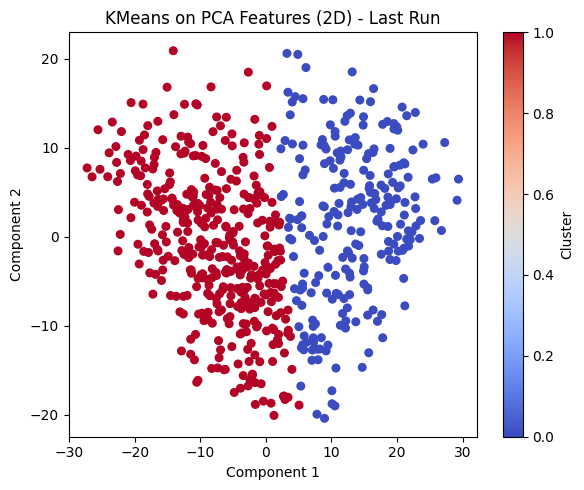

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z   = pca.fit_transform(F)   # Z is now (N, 2)

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
nmi_scores  = []

print("==== Running KMeans on PCA (2D) Features Across Multiple Runs ====\n")

for run in range(num_runs):
    print(f"--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)

    # -------- KMEANS ON 2D PCA FEATURES --------
    kmeans_pca = KMeans(n_clusters=2, random_state=run, max_iter=5000, n_init=10)
    kmeans_pca.fit(Z)

    probs_pca = kmeans_pca.transform(Z)
    probs_pca = probs_pca / probs_pca.sum(axis=1, keepdims=True)

    y_pred_pca = np.argmax(probs_pca, axis=1)

    # Fix label flip
    acc     = accuracy_score(y_labels, y_pred_pca)
    acc_inv = accuracy_score(y_labels, 1 - y_pred_pca)
    if acc_inv > acc:
        y_pred_pca          = 1 - y_pred_pca
        probs_pca[:, [0,1]] = probs_pca[:, [1,0]]
        acc                 = acc_inv

    prec = precision_score(y_labels, y_pred_pca, zero_division=0)
    rec  = recall_score(y_labels, y_pred_pca,    zero_division=0)
    f1   = f1_score(y_labels, y_pred_pca,        zero_division=0)
    ll   = log_loss(y_labels, probs_pca[:, 1])
    nmi  = normalized_mutual_info_score(y_labels, y_pred_pca, average_method='arithmetic')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(ll)
    nmi_scores.append(nmi)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

print("\n================ FINAL SUMMARY (KMeans on PCA 2D) ================ শিরোনাম\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00b1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  \u00b1 {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} \u00b1 {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  \u00b1 {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  \u00b1 {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  \u00b1 {np.std(nmi_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  \u00b1 {np.std(log_losses):.4f}")

# -------- PLOT (Displaying for the last run) --------
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_pred_pca, cmap='coolwarm', s=30)
plt.title("KMeans on PCA Features (2D) - Last Run")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()